# DistalSeq Pipeline Results — Exploration

Explores the freshly-generated results from `run_all.sh` (run 2026-04-08/09).

**Samples**

| Group | Samples | Vector |
|-------|---------|--------|
| D6941 | R1, R2, R3 | PL27421 |
| D6886 | R1, R2, R3 | PL27128 |
| D8751 | R1, R2, R3 | PL31174 |

**Key output files per sample** (at `s3://fvl58-prod-pipelines-execution-data/results/{sample}/distal-seq/{run_id}/`):
- `{sample}.combined.ToHGandPLV.ReadInfo.additions.tsv.gz` — one row per read, alignment + integration call
- `{sample}.combined.ToHGandPLV.AlnInfo.tsv.gz` — one row per alignment
- `{sample}.ONTReads.ToHGandPLV.merged.bam` — aligned BAM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import s3fs

sns.set_theme(style="whitegrid", font_scale=1.1)

BASE = "s3://fvl58-prod-pipelines-execution-data/results"
PIPELINE = "distal-seq"

# Most-recent run IDs per sample (from run_all.sh executed 2026-04-08/09)
SAMPLES = {
    "DISTAL_D6941_R1": {"run_id": "2026-04-08T16:29:42.318", "vector": "PL27421", "group": "D6941"},
    "DISTAL_D6941_R2": {"run_id": "2026-04-08T17:56:59.899", "vector": "PL27421", "group": "D6941"},
    "DISTAL_D6941_R3": {"run_id": "2026-04-08T18:59:54.306", "vector": "PL27421", "group": "D6941"},
    "DISTAL_D6886_R1": {"run_id": "2026-04-08T20:20:02.431", "vector": "PL27128", "group": "D6886"},
    "DISTAL_D6886_R2": {"run_id": "2026-04-08T21:12:48.251", "vector": "PL27128", "group": "D6886"},
    "DISTAL_D6886_R3": {"run_id": "2026-04-08T21:30:01.221", "vector": "PL27128", "group": "D6886"},
    "DISTAL_D8751_R1": {"run_id": "2026-04-08T23:03:37.431", "vector": "PL31174", "group": "D8751"},
    "DISTAL_D8751_R2": {"run_id": "2026-04-09T00:31:59.110", "vector": "PL31174", "group": "D8751"},
    "DISTAL_D8751_R3": {"run_id": "2026-04-09T02:01:51.136", "vector": "PL31174", "group": "D8751"},
}

# Negative control samples (no D in name) — same donor groups, untransduced
CTRL_SAMPLES = {
    "DISTAL_6941_R1": {"run_id": "2026-04-08T19:48:59.550", "vector": "PL27421", "group": "D6941"},
    "DISTAL_6941_R2": {"run_id": "2026-04-08T19:58:18.239", "vector": "PL27421", "group": "D6941"},
    "DISTAL_6941_R3": {"run_id": "2026-04-08T20:08:39.635", "vector": "PL27421", "group": "D6941"},
    "DISTAL_6886_R1": {"run_id": "2026-04-08T22:37:45.721", "vector": "PL27128", "group": "D6886"},
    "DISTAL_6886_R2": {"run_id": "2026-04-08T22:47:27.300", "vector": "PL27128", "group": "D6886"},
    "DISTAL_6886_R3": {"run_id": "2026-04-08T22:57:12.501", "vector": "PL27128", "group": "D6886"},
    "DISTAL_8751_R1": {"run_id": "2026-04-09T02:54:08.610", "vector": "PL31174", "group": "D8751"},
    "DISTAL_8751_R2": {"run_id": "2026-04-09T03:06:03.923", "vector": "PL31174", "group": "D8751"},
    "DISTAL_8751_R3": {"run_id": "2026-04-09T03:13:43.067", "vector": "PL31174", "group": "D8751"},  # no ReadInfo
}

# Human-readable group labels for legends / titles
GROUP_LABELS = {
    "D6941": "VingiUTRs+GFP",
    "D6886": "wtVingiUTRs+GFP",
    "D8751": "VingiUTRs+CAR-T",
}

SAMPLE_ORDER = list(SAMPLES.keys())
GROUP_ORDER  = ["D6941", "D6886", "D8751"]
PALETTE      = dict(zip(GROUP_ORDER, sns.color_palette("tab10", 3)))
FRAC_COV_COLS = ["FracCov_prom", "FracCov_Kozak", "FracCov_GFP",
                 "FracCov_5pUTR", "FracCov_pA", "FracCov_3pUTR"]

def s3_path(sample, suffix):
    meta = SAMPLES[sample]
    return f"{BASE}/{sample}/{PIPELINE}/{meta['run_id']}/{sample}.{suffix}"

print("Config OK — samples:", len(SAMPLES), "| ctrl samples:", len(CTRL_SAMPLES))

Config OK — samples: 9 | ctrl samples: 9


## 1. Load ReadInfo data

Read the `combined.ToHGandPLV.ReadInfo.additions.tsv.gz` file for every sample directly from S3.

In [2]:
# Only load columns actually used downstream — drops ~50 unused columns (~60% memory reduction)
KEEP_COLS = [
    "Read_Name", "Read_Len", "Num_VectorAln",
    "Proper", "ProperRead", "Valid_NumAln",
    "UnalnEnds_Limit", "WithinVectorAln_UnalnGAPs_Limit", "Expected_IntOrientation",
    "Complete", "Functional", "Truncation", "Inversion",
    "Truncated_5pUTR", "Truncated_pA", "Truncated_GFP",
    "Truncated_Kozak", "Truncated_prom", "Truncated_3pUTR",
    "FracCov_prom", "FracCov_Kozak", "FracCov_GFP",
    "FracCov_5pUTR", "FracCov_pA", "FracCov_3pUTR",
    "Human_Chr", "human_IS",
]

frames = []
for sample, meta in SAMPLES.items():
    path = s3_path(sample, "combined.ToHGandPLV.ReadInfo.additions.tsv.gz")
    df = pd.read_csv(path, sep="\t", compression="gzip",
                     usecols=KEEP_COLS, low_memory=False)
    df["sample"] = sample
    df["vector"] = meta["vector"]
    df["group"]  = meta["group"]
    frames.append(df)
    print(f"  {sample}: {len(df):>8,} reads")

rdf = pd.concat(frames, ignore_index=True)

# Coerce boolean-like columns that may have loaded as object
bool_cols = ["Proper", "ProperRead", "Valid_NumAln", "UnalnEnds_Limit",
             "WithinVectorAln_UnalnGAPs_Limit", "Expected_IntOrientation",
             "Complete", "Functional", "Truncation", "Inversion"]
for c in bool_cols:
    if c in rdf.columns:
        rdf[c] = rdf[c].map({True: True, False: False, "True": True, "False": False})

print(f"\nTotal: {len(rdf):,} reads | {rdf['sample'].nunique()} samples | columns: {rdf.shape[1]}")
rdf.head(2)

  DISTAL_D6941_R1:  117,029 reads
  DISTAL_D6941_R2:  103,769 reads
  DISTAL_D6941_R3:   56,677 reads
  DISTAL_D6886_R1:   43,724 reads
  DISTAL_D6886_R2:    7,074 reads
  DISTAL_D6886_R3:   65,362 reads
  DISTAL_D8751_R1:  158,002 reads
  DISTAL_D8751_R2:  146,625 reads
  DISTAL_D8751_R3:   94,599 reads

Total: 792,861 reads | 9 samples | columns: 30


,Read_Name,Read_Len,Num_VectorAln,Human_Chr,Proper,FracCov_5pUTR,FracCov_pA,FracCov_GFP,FracCov_Kozak,FracCov_prom,...,Inversion,Truncated_5pUTR,Truncated_pA,Truncated_GFP,Truncated_Kozak,Truncated_prom,Truncated_3pUTR,sample,vector,group
0,0000f99a-3248-499b-9fc8-d0a18cb3ea5e,3522,1,chr6,False,0.568807,1.0,1.0,1.0,0.882206,...,False,False,False,False,False,False,False,DISTAL_D6941_R1,PL27421,D6941
1,0003d6be-4f0a-4f71-945b-74d4e4ecc607,2901,1,chr20,False,0.000000,0.0,0.0,0.0,0.541353,...,False,False,False,False,False,False,False,DISTAL_D6941_R1,PL27421,D6941


## 1b. Raw read counts and vector hit rate

- **`raw_total`** — all reads from the flow cell, from `NanoStats.txt` in the upstream `nf_ont_dorado` QC output (NanoPlot)
- **`n_has_vector`** — reads in the ReadInfo file with ≥1 vector alignment (`Num_VectorAln > 0`)
- **`pct_with_vector`** — `n_has_vector / raw_total`

,sample,vector,group,raw_total,n_has_vector,pct_with_vector
0,DISTAL_D6941_R1,PL27421,D6941,4224731,116996,2.77
1,DISTAL_D6941_R2,PL27421,D6941,4129189,103724,2.51
2,DISTAL_D6941_R3,PL27421,D6941,1816959,56653,3.12
3,DISTAL_D6886_R1,PL27128,D6886,3414130,43698,1.28
4,DISTAL_D6886_R2,PL27128,D6886,411070,7070,1.72
5,DISTAL_D6886_R3,PL27128,D6886,6581826,65333,0.99
6,DISTAL_D8751_R1,PL31174,D8751,3721460,157860,4.24
7,DISTAL_D8751_R2,PL31174,D8751,3693243,146576,3.97
8,DISTAL_D8751_R3,PL31174,D8751,2308016,94554,4.10


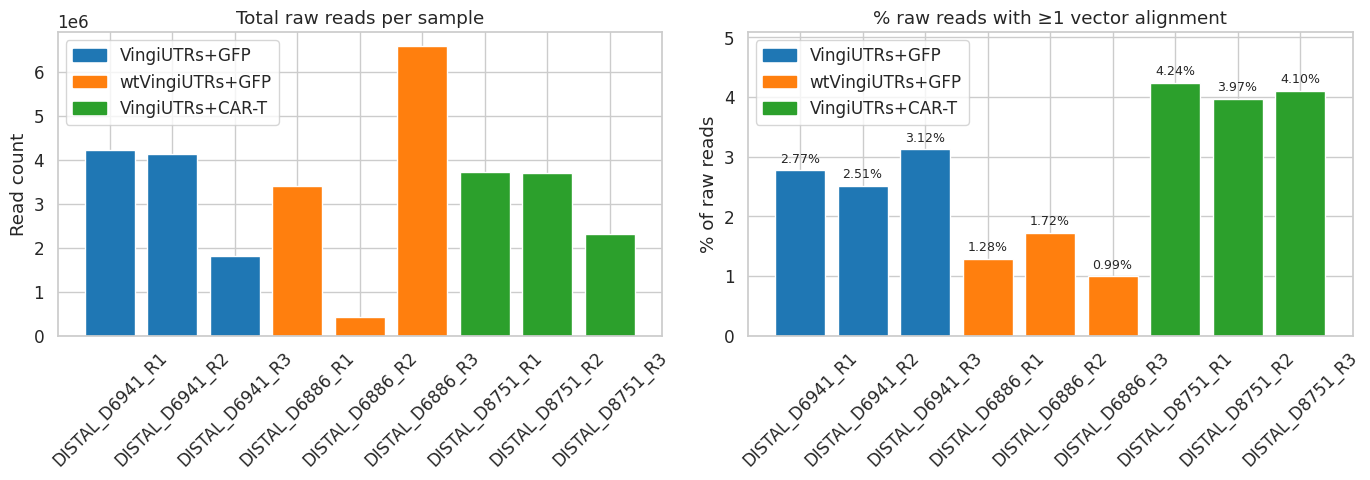

In [3]:
import subprocess

# Dorado run timestamps — extracted from params_jsons FASTQ paths
DORADO_TS = {
    "DISTAL_D6941_R1": "2026-04-04T04:55:37.614",
    "DISTAL_D6941_R2": "2026-04-04T04:53:27.062",
    "DISTAL_D6941_R3": "2026-04-04T04:51:11.525",
    "DISTAL_D6886_R1": "2026-04-04T04:52:41.968",
    "DISTAL_D6886_R2": "2026-04-06T19:45:19.838",
    "DISTAL_D6886_R3": "2026-04-05T07:39:35.380",
    "DISTAL_D8751_R1": "2026-04-04T04:55:33.283",
    "DISTAL_D8751_R2": "2026-04-04T04:55:37.554",
    "DISTAL_D8751_R3": "2026-04-04T00:09:01.539",
}

CTRL_DORADO_TS = {
    "DISTAL_6941_R1": "2026-04-04T04:13:23.071",
    "DISTAL_6941_R2": "2026-04-06T16:14:08.893",
    "DISTAL_6941_R3": "2026-04-06T16:14:34.411",
    "DISTAL_6886_R1": "2026-04-06T19:34:44.532",
    "DISTAL_6886_R2": "2026-04-06T16:11:31.091",
    "DISTAL_6886_R3": "2026-04-06T16:13:43.498",
    "DISTAL_8751_R1": "2026-04-06T16:10:02.383",
    "DISTAL_8751_R2": "2026-04-06T16:09:57.331",
    "DISTAL_8751_R3": "2026-04-06T16:10:02.505",
}

def read_nanostats(sample, ts_map=None):
    """Read number_of_reads from NanoPlot NanoStats.txt in the upstream nf_ont_dorado output."""
    if ts_map is None:
        ts_map = DORADO_TS
    ts = ts_map.get(sample)
    if ts is None:
        return None
    path = (f"s3://fvl58-prod-pipelines-execution-data/results/nf_ont_dorado"
            f"/{sample}/ont_dorado-nf/{ts}/qc/NanoPlot/NanoStats.txt")
    r = subprocess.run(["aws", "s3", "cp", path, "-"], capture_output=True, text=True)
    if r.returncode != 0:
        return None
    for line in r.stdout.splitlines():
        if line.startswith("number_of_reads"):
            return int(line.split()[1])
    return None

raw_all  = {s: read_nanostats(s)                      for s in SAMPLE_ORDER}
raw_ctrl = {s: read_nanostats(s, CTRL_DORADO_TS) for s in CTRL_SAMPLES}

counts_df = rdf.assign(
    has_vector = rdf["Num_VectorAln"] > 0,
).groupby("sample").agg(
    n_has_vector = ("has_vector", "sum"),
).reindex(SAMPLE_ORDER).reset_index()

counts_df["raw_total"]       = counts_df["sample"].map(raw_all)
counts_df["pct_with_vector"] = (counts_df["n_has_vector"] / counts_df["raw_total"] * 100).round(2)
counts_df["vector"] = counts_df["sample"].map(lambda s: SAMPLES[s]["vector"])
counts_df["group"]  = counts_df["sample"].map(lambda s: SAMPLES[s]["group"])

display(counts_df[["sample", "vector", "group", "raw_total", "n_has_vector", "pct_with_vector"]])

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [PALETTE[SAMPLES[s]["group"]] for s in SAMPLE_ORDER]

bars = axes[0].bar(SAMPLE_ORDER, counts_df["raw_total"], color=colors, edgecolor="white")
# axes[0].bar_label(bars, fmt="%,.0f", padding=4, fontsize=8)
axes[0].set_ylabel("Read count")
axes[0].set_title("Total raw reads per sample")
axes[0].tick_params(axis="x", rotation=45)
handles = [mpatches.Patch(color=PALETTE[g], label=GROUP_LABELS[g]) for g in GROUP_ORDER]
axes[0].legend(handles=handles)

pct = counts_df["pct_with_vector"].values
bars2 = axes[1].bar(SAMPLE_ORDER, pct, color=colors, edgecolor="white")
axes[1].set_ylabel("% of raw reads")
axes[1].set_title("% raw reads with ≥1 vector alignment")
axes[1].set_ylim(0, max(pct) * 1.2)
axes[1].tick_params(axis="x", rotation=45)
for i, p in enumerate(pct):
    axes[1].text(i, p + max(pct) * 0.02, f"{p:.2f}%", ha="center", va="bottom", fontsize=9)
axes[1].legend(handles=handles)

plt.tight_layout()
plt.show()

## 1c. Vector hit rate — sequenced vs. negative controls

Grouped mean ± SD across replicates (n=3 per group).  
`DISTAL_D####` = sequenced (transduced); `DISTAL_####` = negative controls (untransduced).  
Log y-scale used because values span ~3 orders of magnitude.  
`DISTAL_8751_R3` has no ReadInfo file (zero vector alignments detected) → treated as 0.

  DISTAL_6941_R1:      9 reads with vector aln
  DISTAL_6941_R2:      3 reads with vector aln
  DISTAL_6941_R3:      8 reads with vector aln
  DISTAL_6886_R1:      5 reads with vector aln
  DISTAL_6886_R2:      2 reads with vector aln
  DISTAL_6886_R3:      2 reads with vector aln
  DISTAL_8751_R1:      3 reads with vector aln
  DISTAL_8751_R2:      0 reads with vector aln
  DISTAL_8751_R3:      0 reads with vector aln
group         mean          sd
D6886  5713.000000  332.340187
D6941 12748.000000 2702.097704
D8751  4615.333333  289.810858


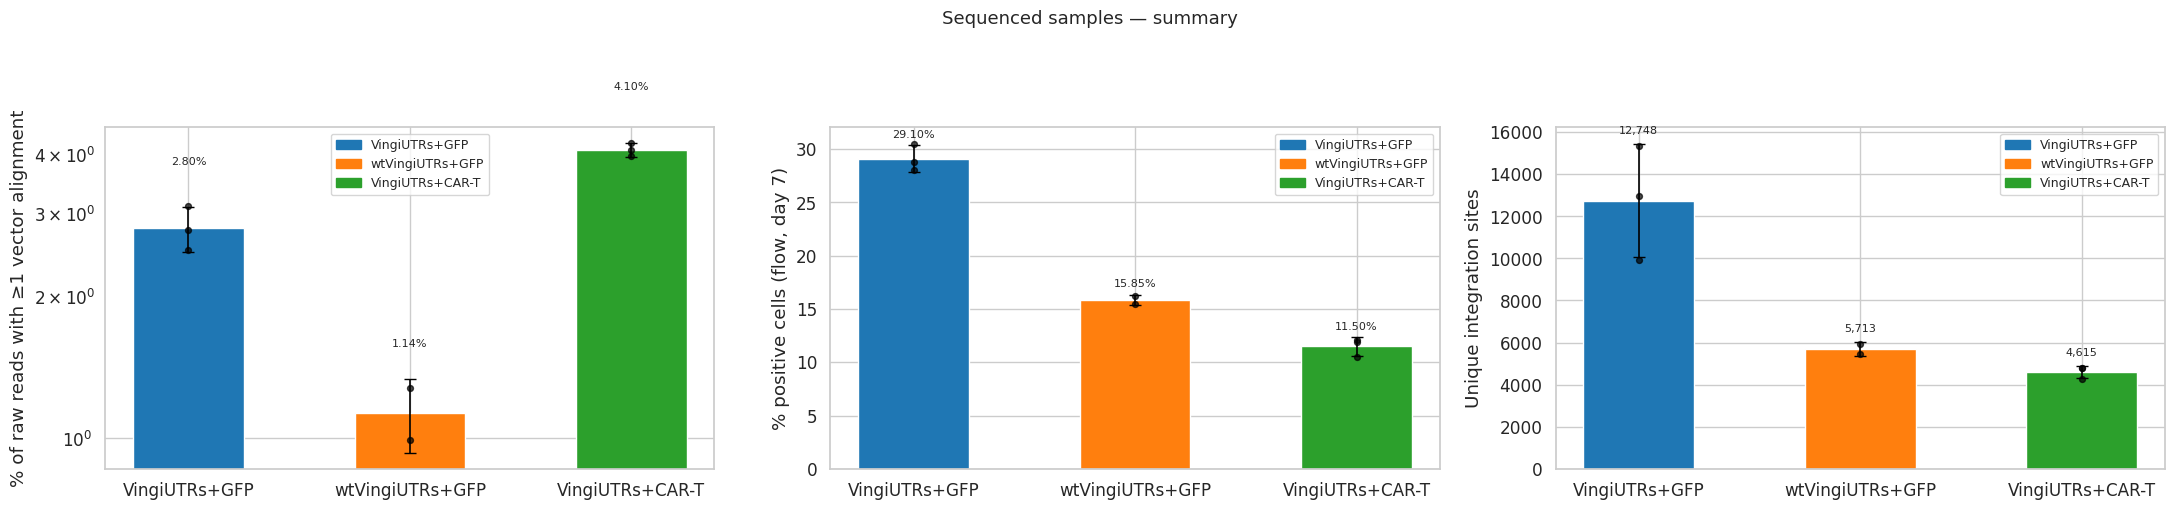


DistalSeq vector hit rate — per sample:


,sample,group,condition,raw_total,n_has_vector,pct_with_vector
0,DISTAL_6886_R1,D6886,ctrl,2973297,5,0.0002
1,DISTAL_6886_R2,D6886,ctrl,2921830,2,0.0001
2,DISTAL_6886_R3,D6886,ctrl,1315601,2,0.0002
3,DISTAL_D6886_R1,D6886,sequenced,3414130,43698,1.2800
4,DISTAL_D6886_R2,D6886,sequenced,411070,7070,1.7200
5,DISTAL_D6886_R3,D6886,sequenced,6581826,65333,0.9900
6,DISTAL_6941_R1,D6941,ctrl,2564112,9,0.0004
7,DISTAL_6941_R2,D6941,ctrl,3144248,3,0.0001
8,DISTAL_6941_R3,D6941,ctrl,3808095,8,0.0002
9,DISTAL_D6941_R1,D6941,sequenced,4224731,116996,2.7700



Unique IS per sample (260409 combined run):


,sample_short,n_unique_IS,group,group_label
0,D6886_R1,5478,D6886,wtVingiUTRs+GFP
1,D6886_R2,1916,D6886,wtVingiUTRs+GFP
2,D6886_R3,5948,D6886,wtVingiUTRs+GFP
3,D6941_R1,15330,D6941,VingiUTRs+GFP
4,D6941_R2,12974,D6941,VingiUTRs+GFP
5,D6941_R3,9940,D6941,VingiUTRs+GFP
6,D8751_R1,4770,D8751,VingiUTRs+CAR-T
7,D8751_R2,4795,D8751,VingiUTRs+CAR-T
8,D8751_R3,4281,D8751,VingiUTRs+CAR-T


In [4]:
import io

# ── Flow cytometry data (Day 7) — defined here so section 12 can reuse it ────
FLOW_D7 = pd.DataFrame([
    # sample                pct    group
    ("DISTAL_D6941_R1",  30.50, "D6941"),
    ("DISTAL_D6941_R2",  28.00, "D6941"),
    ("DISTAL_D6941_R3",  28.80, "D6941"),
    ("DISTAL_6941_R1",    0.06, "D6941"),
    ("DISTAL_6941_R2",    0.09, "D6941"),
    ("DISTAL_6941_R3",    0.06, "D6941"),
    ("DISTAL_D6886_R1",  16.20, "D6886"),
    ("DISTAL_D6886_R2",  16.20, "D6886"),
    ("DISTAL_D6886_R3",  15.50, "D6886"),
    ("DISTAL_6886_R1",    0.06, "D6886"),
    ("DISTAL_6886_R2",    0.10, "D6886"),
    ("DISTAL_6886_R3",    0.04, "D6886"),
    ("DISTAL_D8751_R1",  12.10, "D8751"),
    ("DISTAL_D8751_R2",  11.90, "D8751"),
    ("DISTAL_D8751_R3",  10.50, "D8751"),
    ("DISTAL_8751_R1",    0.03, "D8751"),
    ("DISTAL_8751_R2",    0.01, "D8751"),
    ("DISTAL_8751_R3",    0.01, "D8751"),
], columns=["sample", "pct", "group"])
FLOW_D7["condition"] = FLOW_D7["sample"].str.contains("DISTAL_D").map(
    {True: "sequenced", False: "ctrl"})

# ── IS matrix — unique sites per sample from 260409 combined run ──────────────
IS_MATRIX_S3 = (
    "s3://compbio-discovery-shared/nonLTR/distalseq/results/260409/"
    "DISTAL_D6886_D6941_D8751/260409.IS_matrix.tsv"
)
print("Downloading IS matrix …", end=" ")
subprocess.run(["aws", "s3", "cp", IS_MATRIX_S3, "/tmp/260409_IS_matrix.tsv"],
               check=True, capture_output=True)
print("done")

is_mat    = pd.read_csv("/tmp/260409_IS_matrix.tsv", sep="\t", index_col=0)
samp_cols = [c for c in is_mat.columns if c.startswith("D") and "_R" in c]
n_uniq    = (is_mat[samp_cols] > 0).sum().rename("n_unique_IS").reset_index()
n_uniq.columns = ["sample_short", "n_unique_IS"]
n_uniq["group"] = n_uniq["sample_short"].str.split("_R").str[0]   # D6886_R1 → D6886

# ── Count ctrl vector reads (streaming, no Python memory) ────────────────────
def count_vector_reads_s3(sample, run_id):
    """Stream-count reads with Num_VectorAln > 0 directly from S3 via awk — zero pandas memory."""
    path = f"{BASE}/{sample}/{PIPELINE}/{run_id}/{sample}.combined.ToHGandPLV.ReadInfo.additions.tsv.gz"
    cmd = (
        f"aws s3 cp '{path}' - 2>/dev/null | zcat "
        f"| awk -F'\\t' '"
        f"NR==1{{for(i=1;i<=NF;i++) if($i==\"Num_VectorAln\") col=i}} "
        f"NR>1 && col && $col+0>0 {{n++}} "
        f"END{{print n+0}}'"
    )
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if not r.stdout.strip():
        return 0
    return int(r.stdout.strip())

ctrl_hits = []
for sample, meta in CTRL_SAMPLES.items():
    n_vec = count_vector_reads_s3(sample, meta["run_id"])
    print(f"  {sample}: {n_vec:>6,} reads with vector aln")
    ctrl_hits.append({
        "sample":       sample,
        "group":        meta["group"],
        "n_has_vector": n_vec,
        "raw_total":    raw_ctrl.get(sample),
        "condition":    "ctrl",
    })

ctrl_counts = pd.DataFrame(ctrl_hits)
ctrl_counts["pct_with_vector"] = (
    ctrl_counts["n_has_vector"] / ctrl_counts["raw_total"] * 100).round(4)

main_c = (counts_df[["sample", "group", "n_has_vector", "raw_total", "pct_with_vector"]]
          .assign(condition="sequenced"))
both = pd.concat([main_c, ctrl_counts], ignore_index=True)

FLOOR = 1e-4
both["pct_plot"] = both["pct_with_vector"].clip(lower=FLOOR)

# ── Exclude DISTAL_D6886_R2 from this figure ──────────────────────────────────
EXCLUDE       = {"DISTAL_D6886_R2"}
EXCLUDE_SHORT = {"D6886_R2"}
both_plot   = both[~both["sample"].isin(EXCLUDE)]
flow_plot   = FLOW_D7[~FLOW_D7["sample"].isin(EXCLUDE)]
n_uniq_plot = n_uniq[~n_uniq["sample_short"].isin(EXCLUDE_SHORT)]

agg_seq  = (both_plot[both_plot["condition"] == "sequenced"]
            .groupby("group")["pct_plot"]
            .agg(mean="mean", sd="std").reset_index().fillna({"sd": 0}))
agg_flow = (flow_plot[flow_plot["condition"] == "sequenced"]
            .groupby("group")["pct"]
            .agg(mean="mean", sd="std").reset_index().fillna({"sd": 0}))
agg_is   = (n_uniq_plot.groupby("group")["n_unique_IS"]
            .agg(mean="mean", sd="std").reset_index().fillna({"sd": 0}))
print(agg_is.to_string(index=False))

# ── Three-panel figure ────────────────────────────────────────────────────────
bar_w = 0.5
x     = np.arange(len(GROUP_ORDER))

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# ── Panels 1 & 2: sequenced only ─────────────────────────────────────────────
for ax, agg, ylabel, use_log, seq_data, pct_col in [
    (axes[0], agg_seq,  "% of raw reads with ≥1 vector alignment", True,  both_plot, "pct_plot"),
    (axes[1], agg_flow, "% positive cells (flow, day 7)",          False, flow_plot, "pct"),
]:
    sub   = agg.set_index("group").reindex(GROUP_ORDER)
    means = sub["mean"].values
    sds   = sub["sd"].values

    ax.bar(x, means, bar_w,
           color=[PALETTE[g] for g in GROUP_ORDER], edgecolor="white")
    yerr_lo = np.minimum(sds, means - FLOOR) if use_log else sds
    ax.errorbar(x, means, yerr=[yerr_lo, sds],
                fmt="none", color="black", capsize=4, lw=1.2)

    seq_rows = seq_data[seq_data["condition"] == "sequenced"]
    for j, grp in enumerate(GROUP_ORDER):
        pts = seq_rows.loc[seq_rows["group"] == grp, pct_col].values
        ax.scatter(np.full(len(pts), x[j]), pts,
                   color="black", s=18, zorder=5, alpha=0.7)

    for xi, grp in enumerate(GROUP_ORDER):
        v = sub.loc[grp, "mean"];  e = sub.loc[grp, "sd"]
        ypos  = v * 10**(0.12 + 0.08*(e/v if v else 0)) if use_log else v + e + 0.5
        label = (f"{v:.3f}%" if v < 1 else f"{v:.2f}%") if use_log else f"{v:.2f}%"
        ax.text(x[xi], ypos, label, ha="center", va="bottom", fontsize=8)

    if use_log:
        ax.set_yscale("log")
    ax.set_xticks(x);  ax.set_xticklabels([GROUP_LABELS[g] for g in GROUP_ORDER])
    ax.set_ylabel(ylabel)

# ── Panel 3: unique IS from 260409 combined pipeline results ─────────────────
ax3   = axes[2]
sub3  = agg_is.set_index("group").reindex(GROUP_ORDER)
means = sub3["mean"].values;  sds = sub3["sd"].values
ax3.bar(x, means, bar_w,
        color=[PALETTE[g] for g in GROUP_ORDER], edgecolor="white")
ax3.errorbar(x, means, yerr=sds, fmt="none", color="black", capsize=4, lw=1.2)
for j, grp in enumerate(GROUP_ORDER):
    pts = n_uniq_plot.loc[n_uniq_plot["group"] == grp, "n_unique_IS"].values
    ax3.scatter(np.full(len(pts), x[j]), pts,
                color="black", s=18, zorder=5, alpha=0.7)
for xi in range(len(GROUP_ORDER)):
    v = means[xi];  e = sds[xi]
    ax3.text(xi, v + e + sub3["mean"].max() * 0.03,
             f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
ax3.set_xticks(x);  ax3.set_xticklabels([GROUP_LABELS[g] for g in GROUP_ORDER])
ax3.set_ylabel("Unique integration sites")

# ── Shared legend ─────────────────────────────────────────────────────────────
color_handles = [mpatches.Patch(color=PALETTE[g], label=GROUP_LABELS[g]) for g in GROUP_ORDER]
for ax in axes:
    ax.legend(handles=color_handles, fontsize=9)

plt.suptitle("Sequenced samples — summary", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nDistalSeq vector hit rate — per sample:")
display(both[["sample", "group", "condition", "raw_total", "n_has_vector", "pct_with_vector"]]
        .sort_values(["group", "condition", "sample"]).reset_index(drop=True))
print("\nUnique IS per sample (260409 combined run):")
display(n_uniq.assign(group_label=n_uniq["group"].map(GROUP_LABELS))
        .sort_values("group").reset_index(drop=True))

## 1d. Alignment count distribution — vector × human

Per-read cross-tabulation of `Num_VectorAln` × `Num_HumanAln`, binned at 3+.  
Values are % of all reads. Reproduces `260409.QC.Pipeline_Stats.AllReads.alm_rlen_filtered_heatmap.perc.png`.

Streaming alignment counts …
  DISTAL_D6941_R1: done
  DISTAL_D6941_R2: done
  DISTAL_D6941_R3: done
  DISTAL_D6886_R1: done
  DISTAL_D6886_R2: done
  DISTAL_D6886_R3: done
  DISTAL_D8751_R1: done
  DISTAL_D8751_R2: done
  DISTAL_D8751_R3: done


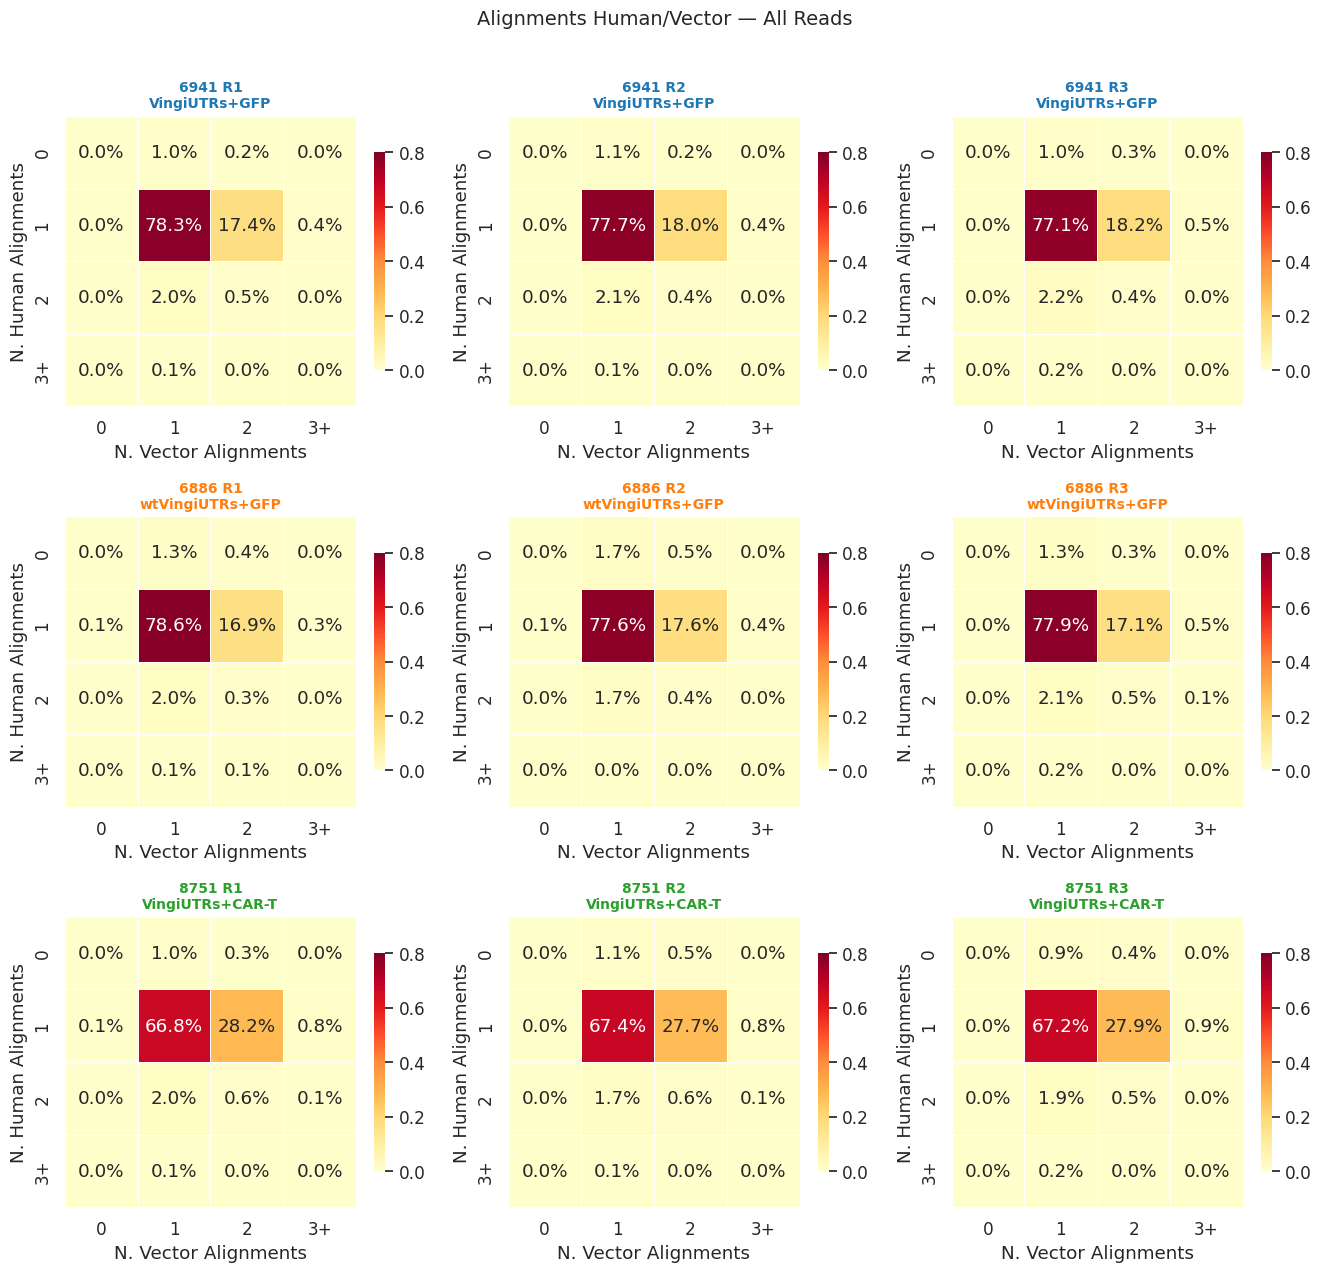

In [5]:
def get_aln_cross(sample, meta):
    """Stream Num_VectorAln × Num_HumanAln cross-counts from S3 via awk. Returns fraction matrix."""
    path = (f"{BASE}/{sample}/{PIPELINE}/{meta['run_id']}/"
            f"{sample}.combined.ToHGandPLV.ReadInfo.additions.tsv.gz")
    cmd = (
        f"aws s3 cp '{path}' - 2>/dev/null | zcat | awk -F'\\t' '"
        f"NR==1{{for(i=1;i<=NF;i++){{if($i==\"Num_VectorAln\")vc=i;if($i==\"Num_HumanAln\")hc=i}}}} "
        f"NR>1{{v=($vc+0>=3)?3:$vc+0;h=($hc+0>=3)?3:$hc+0;cnt[v,h]++;tot++}} "
        f"END{{for(k in cnt){{split(k,a,SUBSEP);print a[1],a[2],cnt[k],tot}}}}'"
    )
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    bins = [0, 1, 2, 3]
    mat  = pd.DataFrame(0.0, index=bins, columns=bins)
    total = 1
    for line in r.stdout.strip().splitlines():
        parts = line.split()
        v, h, n, tot = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
        mat.loc[h, v] = n
        total = tot
    return mat / total   # fractions (0–1)

print("Streaming alignment counts …")
aln_cross = {}
for sample, meta in SAMPLES.items():
    aln_cross[sample] = get_aln_cross(sample, meta)
    print(f"  {sample}: done")

# ── 3×3 heatmap grid ──────────────────────────────────────────────────────────
ncols      = 3
nrows      = (len(SAMPLE_ORDER) + ncols - 1) // ncols
tick_lbl   = ["0", "1", "2", "3+"]
fig, axes  = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.2))
axes_flat  = axes.flatten()

for ax, sample in zip(axes_flat, SAMPLE_ORDER):
    mat   = aln_cross[sample]
    annot = mat.map(lambda v: f"{v*100:.1f}%") if hasattr(mat, "map") else mat.applymap(lambda v: f"{v*100:.1f}%")
    sns.heatmap(
        mat, ax=ax,
        vmin=0, vmax=0.8,
        cmap="YlOrRd",
        annot=annot, fmt="",
        linewidths=0.4, linecolor="white",
        xticklabels=tick_lbl,
        yticklabels=tick_lbl,
        cbar_kws={"shrink": 0.75},
    )
    grp   = SAMPLES[sample]["group"]
    short = sample.replace("DISTAL_D", "").replace("_", " ")
    ax.set_title(f"{short}\n{GROUP_LABELS[grp]}", color=PALETTE[grp],
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("N. Vector Alignments")
    ax.set_ylabel("N. Human Alignments")

for ax in axes_flat[len(SAMPLE_ORDER):]:
    ax.set_visible(False)

plt.suptitle("Alignments Human/Vector — All Reads", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Read counts per sample

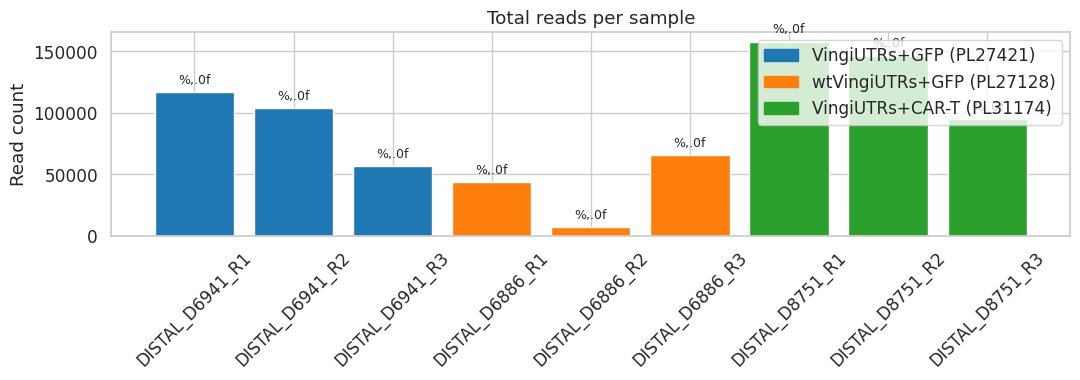

In [6]:
counts = rdf.groupby("sample").size().reindex(SAMPLE_ORDER).reset_index(name="n_reads")
counts["group"] = counts["sample"].map(lambda s: SAMPLES[s]["group"])

fig, ax = plt.subplots(figsize=(11, 4))
colors = [PALETTE[SAMPLES[s]["group"]] for s in SAMPLE_ORDER]
bars = ax.bar(SAMPLE_ORDER, counts["n_reads"], color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%,.0f", padding=4, fontsize=9)
ax.set_ylabel("Read count")
ax.set_title("Total reads per sample")
ax.tick_params(axis="x", rotation=45)
handles = [mpatches.Patch(color=PALETTE[g], label=f"{GROUP_LABELS[g]} ({SAMPLES[next(s for s in SAMPLES if SAMPLES[s]['group']==g)]['vector']})")
           for g in GROUP_ORDER]
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.show()

## 3. Read length distribution

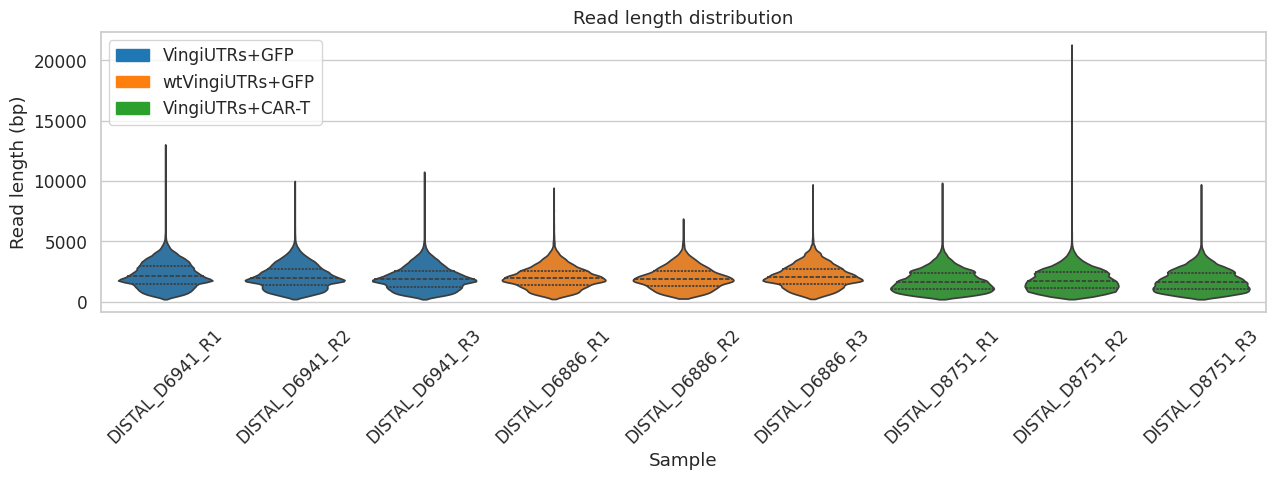

,count,mean,std,min,25%,50%,75%,max
sample,,,,,,,,
DISTAL_D6941_R1,117029.0,2206.0,1029.0,192.0,1441.0,2083.0,2934.0,13039.0
DISTAL_D6941_R2,103769.0,2080.0,974.0,201.0,1348.0,1966.0,2726.0,10001.0
DISTAL_D6941_R3,56677.0,1940.0,923.0,190.0,1243.0,1839.0,2507.0,10767.0
DISTAL_D6886_R1,43724.0,2015.0,896.0,211.0,1379.0,1938.0,2562.0,9438.0
DISTAL_D6886_R2,7074.0,1961.0,893.0,251.0,1308.0,1881.0,2526.0,6875.0
DISTAL_D6886_R3,65362.0,2098.0,926.0,218.0,1437.0,2010.0,2700.0,9721.0
DISTAL_D8751_R1,158002.0,1724.0,887.0,191.0,1020.0,1589.0,2336.0,9853.0
DISTAL_D8751_R2,146625.0,1806.0,899.0,200.0,1095.0,1704.0,2426.0,21312.0
DISTAL_D8751_R3,94599.0,1769.0,889.0,191.0,1052.0,1650.0,2401.0,9725.0


In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(
    data=rdf, x="sample", y="Read_Len",
    order=SAMPLE_ORDER, hue="group", hue_order=GROUP_ORDER,
    palette=PALETTE, cut=0, inner="quartile", legend=False, ax=ax
)
ax.set_xlabel("Sample")
ax.set_ylabel("Read length (bp)")
ax.set_title("Read length distribution")
ax.tick_params(axis="x", rotation=45)
handles = [mpatches.Patch(color=PALETTE[g], label=GROUP_LABELS[g]) for g in GROUP_ORDER]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

rdf.groupby("sample")["Read_Len"].describe().reindex(SAMPLE_ORDER).round(0)

## 4. QC filter pass rates

Each boolean flag in the pipeline captures a specific quality criterion.  
Reads that pass **all** filters become `Valid_NumAln = True`.

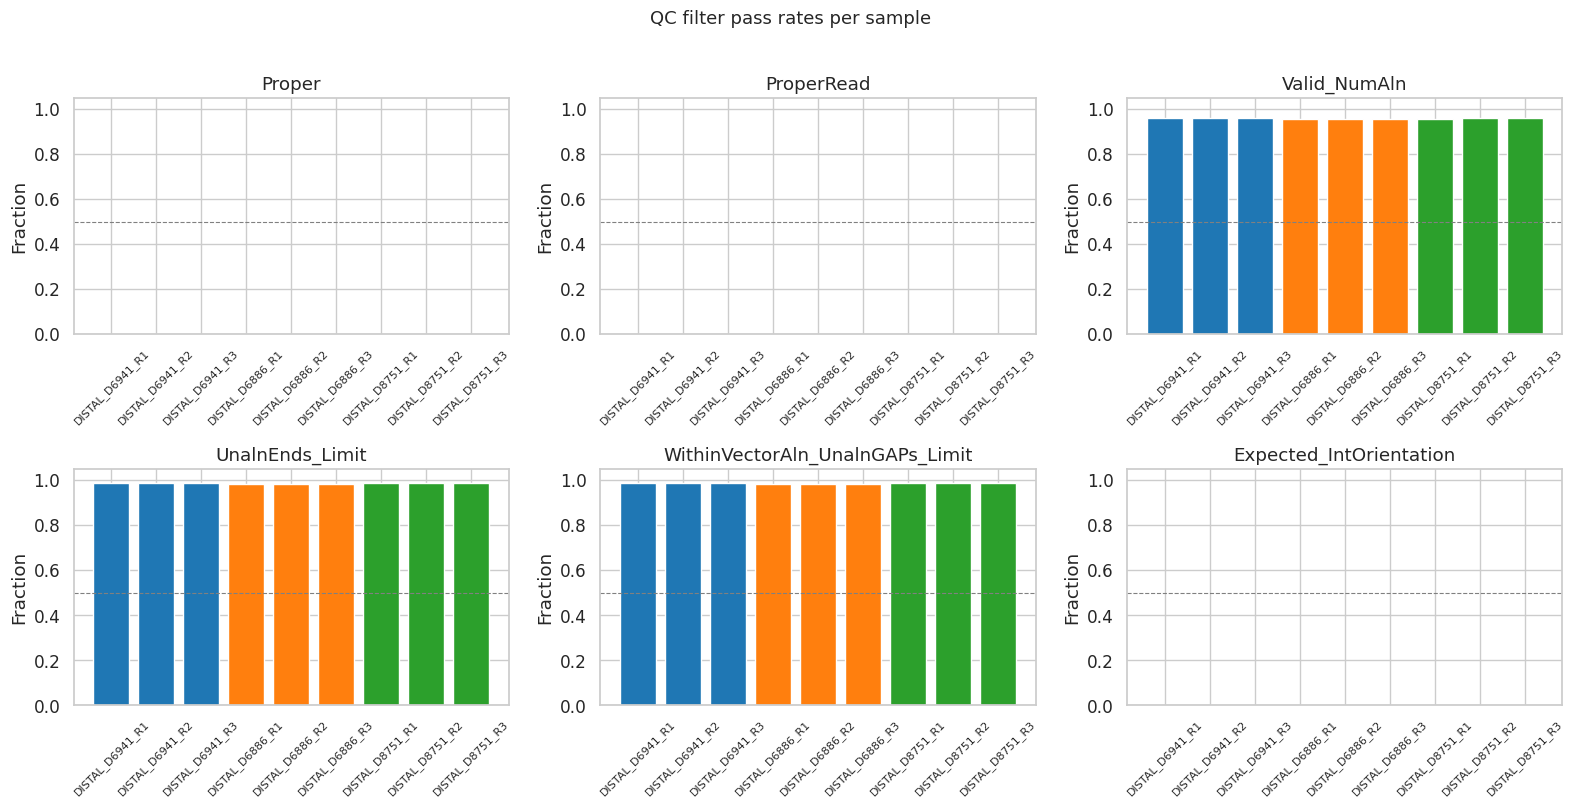

,Proper,ProperRead,Valid_NumAln,UnalnEnds_Limit,WithinVectorAln_UnalnGAPs_Limit,Expected_IntOrientation
sample,,,,,,
DISTAL_D6941_R1,0.000,0.000,0.960,0.987,0.986,0.000
DISTAL_D6941_R2,0.000,0.000,0.960,0.987,0.988,0.001
DISTAL_D6941_R3,0.000,0.000,0.958,0.986,0.986,0.001
DISTAL_D6886_R1,0.000,0.000,0.957,0.982,0.985,0.000
DISTAL_D6886_R2,0.000,0.000,0.956,0.984,0.983,0.001
DISTAL_D6886_R3,0.001,0.001,0.954,0.985,0.983,0.001
DISTAL_D8751_R1,0.000,0.000,0.957,0.986,0.989,0.001
DISTAL_D8751_R2,0.001,0.001,0.959,0.986,0.989,0.001
DISTAL_D8751_R3,0.001,0.001,0.960,0.987,0.989,0.001


In [8]:
QC_COLS = ["Proper", "ProperRead", "Valid_NumAln",
           "UnalnEnds_Limit", "WithinVectorAln_UnalnGAPs_Limit", "Expected_IntOrientation"]

totals = rdf.groupby("sample").size().reindex(SAMPLE_ORDER)
qc_frac = (
    rdf.groupby("sample")[QC_COLS].sum()
    .reindex(SAMPLE_ORDER)
    .div(totals, axis=0)
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, QC_COLS):
    colors = [PALETTE[SAMPLES[s]["group"]] for s in SAMPLE_ORDER]
    ax.bar(SAMPLE_ORDER, qc_frac[col], color=colors, edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Fraction")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.axhline(0.5, color="grey", lw=0.8, ls="--")

plt.suptitle("QC filter pass rates per sample", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

qc_frac.round(3)

## 5. Integration characteristics

Among reads that pass `Valid_NumAln`: what fraction are **Complete**, **Functional**, **Truncated**, or **Inverted**?

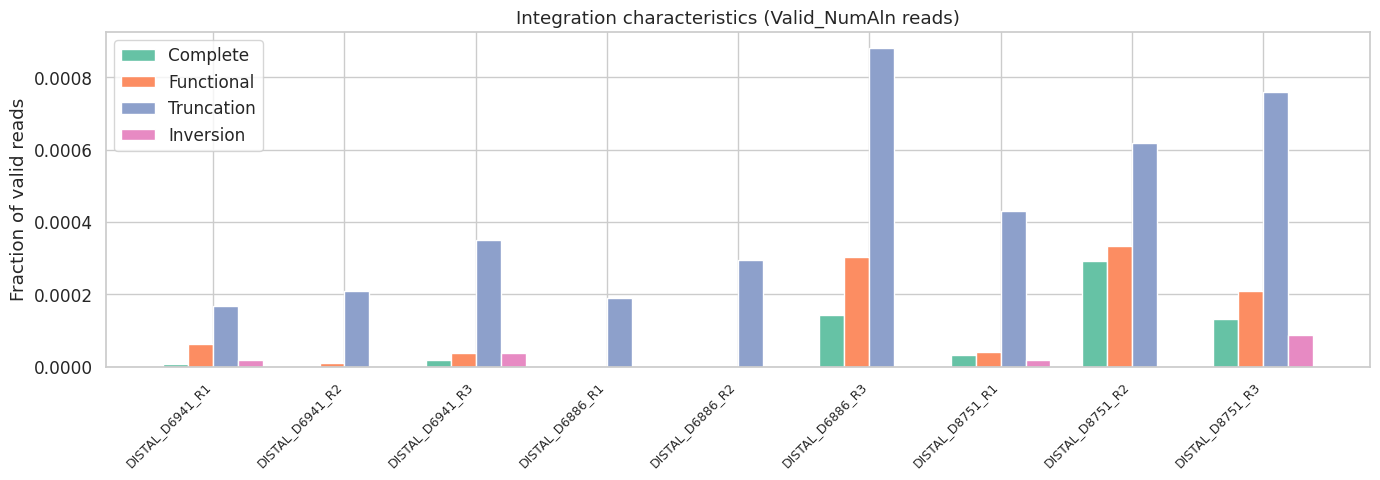

,Complete,Functional,Truncation,Inversion
sample,,,,
DISTAL_D6941_R1,0.0,0.0,0.000,0.0
DISTAL_D6941_R2,0.0,0.0,0.000,0.0
DISTAL_D6941_R3,0.0,0.0,0.000,0.0
DISTAL_D6886_R1,0.0,0.0,0.000,0.0
DISTAL_D6886_R2,0.0,0.0,0.000,0.0
DISTAL_D6886_R3,0.0,0.0,0.001,0.0
DISTAL_D8751_R1,0.0,0.0,0.000,0.0
DISTAL_D8751_R2,0.0,0.0,0.001,0.0
DISTAL_D8751_R3,0.0,0.0,0.001,0.0


In [9]:
valid = rdf[rdf["Valid_NumAln"] == True].copy()

INT_COLS = ["Complete", "Functional", "Truncation", "Inversion"]
v_totals = valid.groupby("sample").size().reindex(SAMPLE_ORDER)
int_frac = (
    valid.groupby("sample")[INT_COLS].sum()
    .reindex(SAMPLE_ORDER)
    .div(v_totals, axis=0)
)

x = np.arange(len(SAMPLE_ORDER))
width = 0.19
fig, ax = plt.subplots(figsize=(14, 5))
colors_int = sns.color_palette("Set2", len(INT_COLS))
for i, (col, color) in enumerate(zip(INT_COLS, colors_int)):
    ax.bar(x + i * width, int_frac[col], width, label=col, color=color, edgecolor="white")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(SAMPLE_ORDER, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Fraction of valid reads")
ax.set_title("Integration characteristics (Valid_NumAln reads)")
ax.legend()
plt.tight_layout()
plt.show()

int_frac.round(3)

## 6. Per-element truncation rates

Among truncated reads: which vector element is most often truncated?

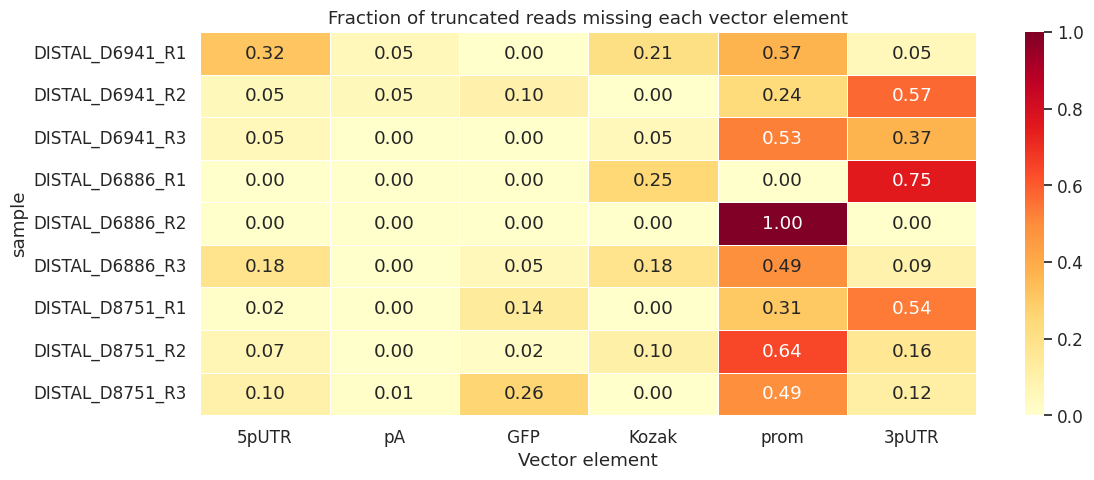

In [10]:
TRUNC_ELEMENT_COLS = ["Truncated_5pUTR", "Truncated_pA", "Truncated_GFP",
                      "Truncated_Kozak", "Truncated_prom", "Truncated_3pUTR"]

trunc_reads = valid[valid["Truncation"] == True].copy()
tr_totals = trunc_reads.groupby("sample").size().reindex(SAMPLE_ORDER)
trunc_frac = (
    trunc_reads.groupby("sample")[TRUNC_ELEMENT_COLS].sum()
    .reindex(SAMPLE_ORDER)
    .div(tr_totals, axis=0)
)
trunc_frac.columns = [c.replace("Truncated_", "") for c in TRUNC_ELEMENT_COLS]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(trunc_frac, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Fraction of truncated reads missing each vector element")
ax.set_xlabel("Vector element")
plt.tight_layout()
plt.show()

## 7. Vector element coverage (FracCov)

Median coverage fraction for each vector element across all valid reads.

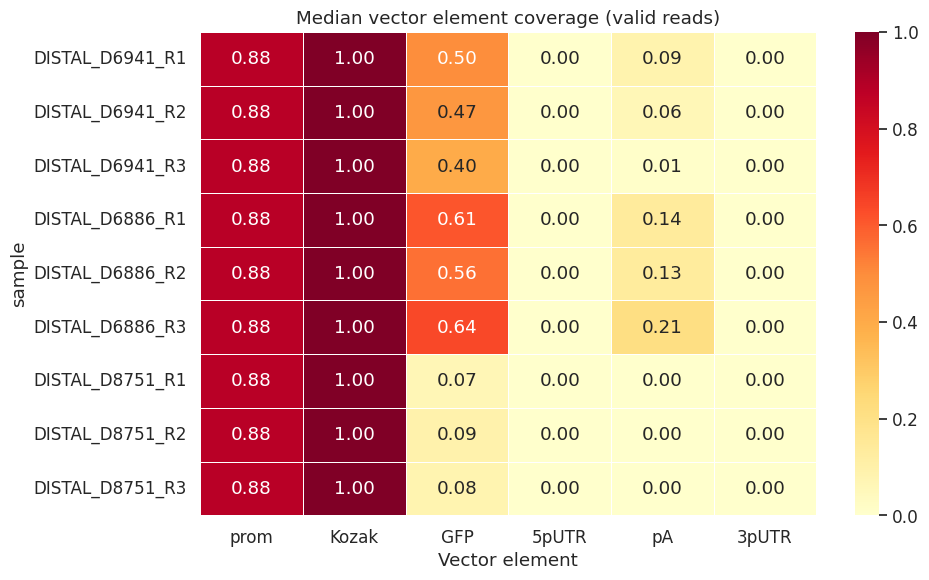

In [11]:
frac_cov_median = (
    valid.groupby("sample")[FRAC_COV_COLS]
    .median()
    .reindex(SAMPLE_ORDER)
)
frac_cov_median.columns = [c.replace("FracCov_", "") for c in FRAC_COV_COLS]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(frac_cov_median, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Median vector element coverage (valid reads)")
ax.set_xlabel("Vector element")
plt.tight_layout()
plt.show()

## 8. Genomic distribution of integration sites

Chromosome-level distribution of `Human_Chr` for valid reads.

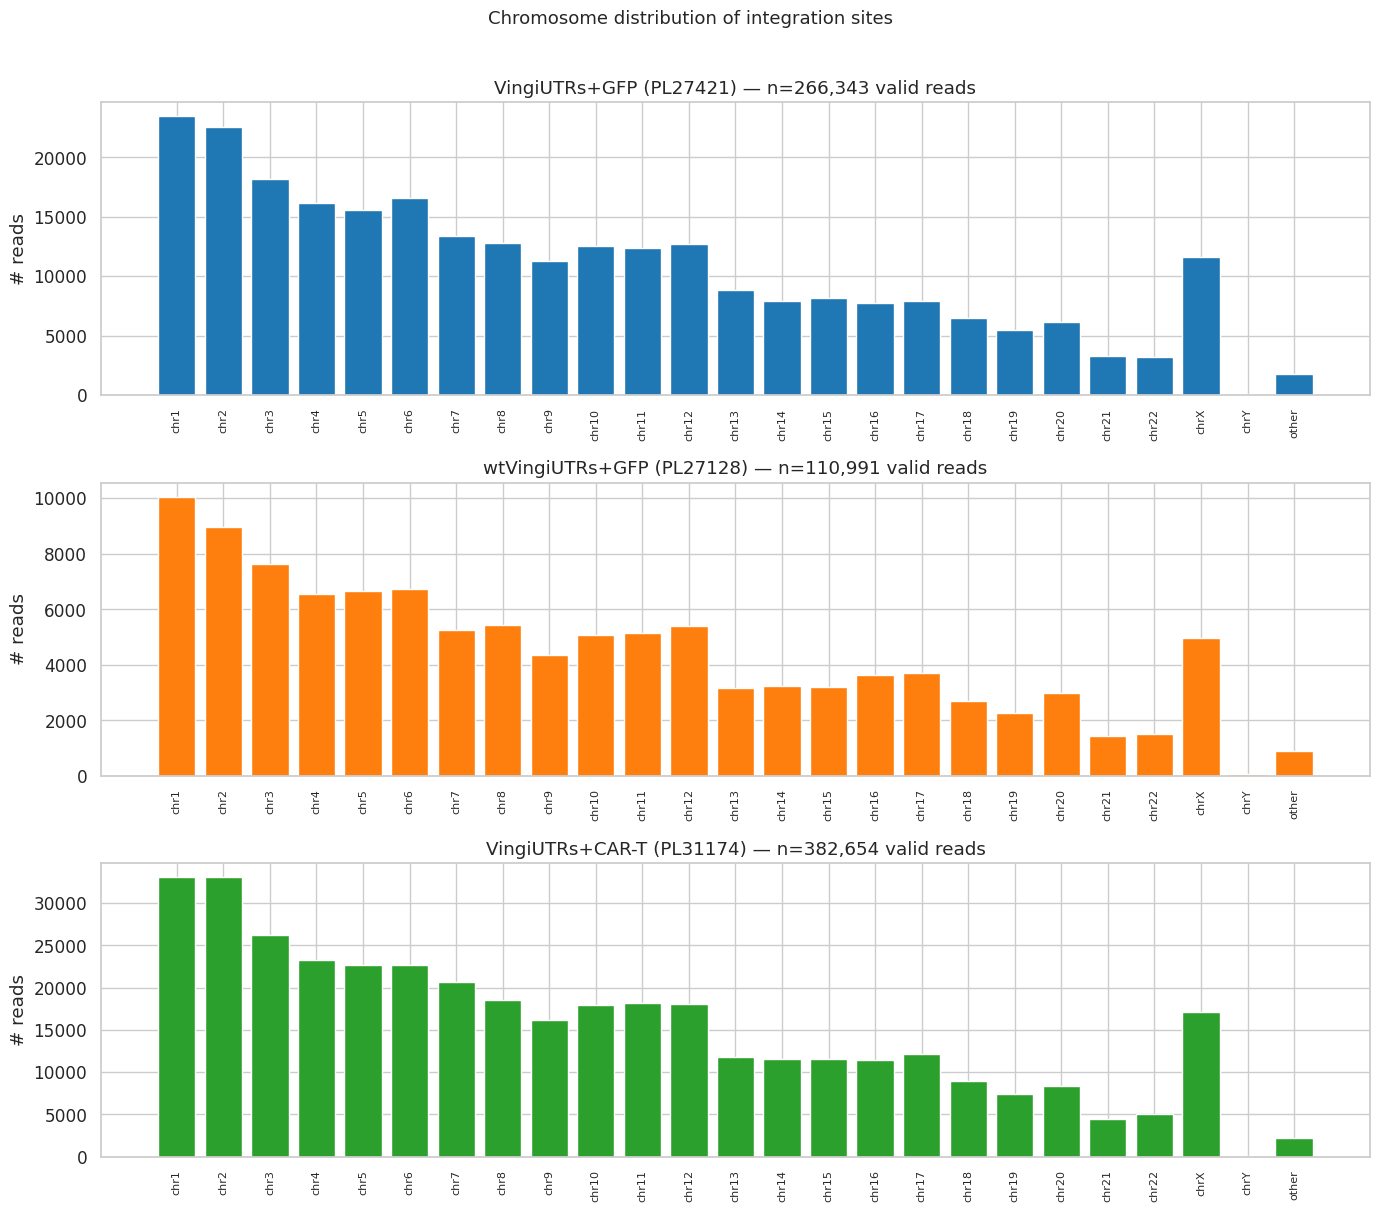

In [12]:
STD_CHROMS = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

valid_chrom = valid[valid["Human_Chr"].notna()].copy()
valid_chrom["chrom_plot"] = valid_chrom["Human_Chr"].where(
    valid_chrom["Human_Chr"].isin(STD_CHROMS), other="other"
)
chrom_order = STD_CHROMS + ["other"]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for ax, grp in zip(axes, GROUP_ORDER):
    sub = valid_chrom[valid_chrom["group"] == grp]
    counts_c = sub["chrom_plot"].value_counts().reindex(chrom_order, fill_value=0)
    ax.bar(chrom_order, counts_c.values, color=PALETTE[grp], edgecolor="white")
    vector = SAMPLES[next(s for s in SAMPLES if SAMPLES[s]["group"] == grp)]["vector"]
    ax.set_title(f"{GROUP_LABELS[grp]} ({vector}) — n={len(sub):,} valid reads")
    ax.set_ylabel("# reads")
    ax.tick_params(axis="x", rotation=90, labelsize=8)

plt.suptitle("Chromosome distribution of integration sites", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 9. Unique integration sites

Collapse `human_IS` values to count distinct sites and site reuse.

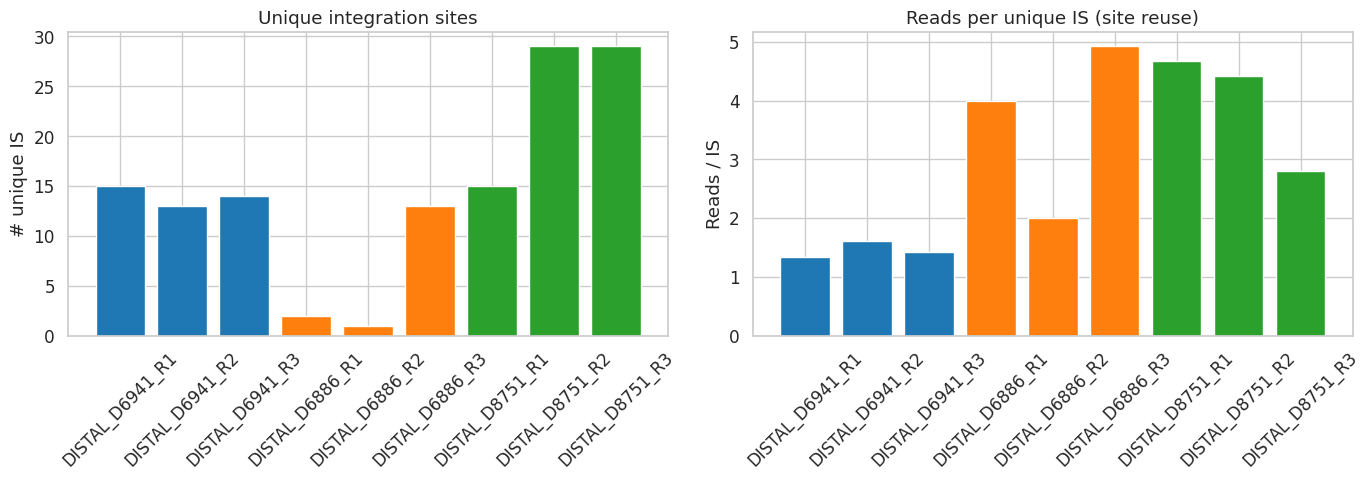

,sample,n_reads,n_unique_IS,reads_per_IS
0,DISTAL_D6941_R1,20,15,1.333333
1,DISTAL_D6941_R2,21,13,1.615385
2,DISTAL_D6941_R3,20,14,1.428571
3,DISTAL_D6886_R1,8,2,4.000000
4,DISTAL_D6886_R2,2,1,2.000000
5,DISTAL_D6886_R3,64,13,4.923077
6,DISTAL_D8751_R1,70,15,4.666667
7,DISTAL_D8751_R2,128,29,4.413793
8,DISTAL_D8751_R3,81,29,2.793103


In [13]:
is_df = valid[valid["human_IS"].notna() & (valid["human_IS"] != "")].copy()

is_summary = (
    is_df.groupby("sample")["human_IS"]
    .agg(n_reads="count", n_unique_IS="nunique")
    .reindex(SAMPLE_ORDER)
    .reset_index()
)
is_summary["reads_per_IS"] = is_summary["n_reads"] / is_summary["n_unique_IS"]
is_summary["group"] = is_summary["sample"].map(lambda s: SAMPLES[s]["group"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [PALETTE[SAMPLES[s]["group"]] for s in SAMPLE_ORDER]

axes[0].bar(SAMPLE_ORDER, is_summary["n_unique_IS"], color=colors, edgecolor="white")
axes[0].set_title("Unique integration sites")
axes[0].set_ylabel("# unique IS")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(SAMPLE_ORDER, is_summary["reads_per_IS"], color=colors, edgecolor="white")
axes[1].set_title("Reads per unique IS (site reuse)")
axes[1].set_ylabel("Reads / IS")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

is_summary.drop(columns="group")

## 10. Top recurrent integration sites

Identify the most frequently captured genomic loci across samples of the same vector.

In [14]:
for grp in GROUP_ORDER:
    sub = is_df[is_df["group"] == grp]
    top = (
        sub.groupby("human_IS")["Read_Name"]
        .count()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
        .rename(columns={"Read_Name": "n_reads", "human_IS": "integration_site"})
    )
    vector = SAMPLES[next(s for s in SAMPLES if SAMPLES[s]["group"] == grp)]["vector"]
    print(f"\n=== {GROUP_LABELS[grp]} ({vector}) — top 15 sites ===")
    display(top)


=== VingiUTRs+GFP (PL27421) — top 15 sites ===


,integration_site,n_reads
0,24302385.0,4
1,1106.0,3
2,29684613.0,3
3,173611863.0,3
4,684.0,2
5,14475259.0,2
6,1141.0,2
7,6678385.0,2
8,1361.0,2
9,858.0,2



=== wtVingiUTRs+GFP (PL27128) — top 15 sites ===


,integration_site,n_reads
0,21014987.0,17
1,1150.0,10
2,1182.0,6
3,60488556.0,6
4,127698693.0,5
5,55838285.0,5
6,46394882.0,5
7,1185.0,5
8,135639919.0,3
9,1077.0,3



=== VingiUTRs+CAR-T (PL31174) — top 15 sites ===


,integration_site,n_reads
0,28732267.0,24
1,2124.0,15
2,2179.0,11
3,2197.0,11
4,53312896.0,11
5,111989702.0,11
6,41736439.0,11
7,2199.0,10
8,97702440.0,10
9,48239974.0,9


## 11. Summary table

In [15]:
summary = rdf.groupby("sample").agg(
    total_reads    = ("Read_Name", "count"),
    median_len_bp  = ("Read_Len", "median"),
    proper_reads   = ("Proper", "sum"),
    valid_reads    = ("Valid_NumAln", "sum"),
).reindex(SAMPLE_ORDER).reset_index()

comp_func = (
    valid.groupby("sample").agg(
        complete   = ("Complete", "sum"),
        functional = ("Functional", "sum"),
        truncated  = ("Truncation", "sum"),
        inverted   = ("Inversion", "sum"),
    ).reindex(SAMPLE_ORDER).reset_index()
)

summary = summary.merge(comp_func, on="sample")
summary["vector"]         = summary["sample"].map(lambda s: SAMPLES[s]["vector"])
summary["group"]          = summary["sample"].map(lambda s: SAMPLES[s]["group"])
summary["proper_%"]       = (summary["proper_reads"]   / summary["total_reads"]   * 100).round(1)
summary["valid_%"]        = (summary["valid_reads"]    / summary["total_reads"]   * 100).round(1)
summary["complete_%"]     = (summary["complete"]       / summary["valid_reads"]   * 100).round(1)
summary["functional_%"]   = (summary["functional"]     / summary["valid_reads"]   * 100).round(1)
summary["truncated_%"]    = (summary["truncated"]      / summary["valid_reads"]   * 100).round(1)

display_cols = ["sample", "vector", "group", "total_reads", "median_len_bp",
                "proper_%", "valid_%", "complete_%", "functional_%", "truncated_%"]
summary[display_cols]

,sample,vector,group,total_reads,median_len_bp,proper_%,valid_%,complete_%,functional_%,truncated_%
0,DISTAL_D6941_R1,PL27421,D6941,117029,2083.0,0.0,96.0,0.0,0.0,0.0
1,DISTAL_D6941_R2,PL27421,D6941,103769,1966.0,0.0,96.0,0.0,0.0,0.0
2,DISTAL_D6941_R3,PL27421,D6941,56677,1839.0,0.0,95.8,0.0,0.0,0.0
3,DISTAL_D6886_R1,PL27128,D6886,43724,1938.0,0.0,95.7,0.0,0.0,0.0
4,DISTAL_D6886_R2,PL27128,D6886,7074,1881.0,0.0,95.6,0.0,0.0,0.0
5,DISTAL_D6886_R3,PL27128,D6886,65362,2010.0,0.1,95.4,0.0,0.0,0.1
6,DISTAL_D8751_R1,PL31174,D8751,158002,1589.0,0.0,95.7,0.0,0.0,0.0
7,DISTAL_D8751_R2,PL31174,D8751,146625,1704.0,0.1,95.9,0.0,0.0,0.1
8,DISTAL_D8751_R3,PL31174,D8751,94599,1650.0,0.1,96.0,0.0,0.0,0.1


## 12. Flow cytometry — Day 7

Percentage of GFP⁺ / CAR-T⁺ cells measured by flow on day 7 post-transduction.  
`DISTAL_D####` rows are the sequenced samples; `DISTAL_####` (no D) are the matched negative controls.

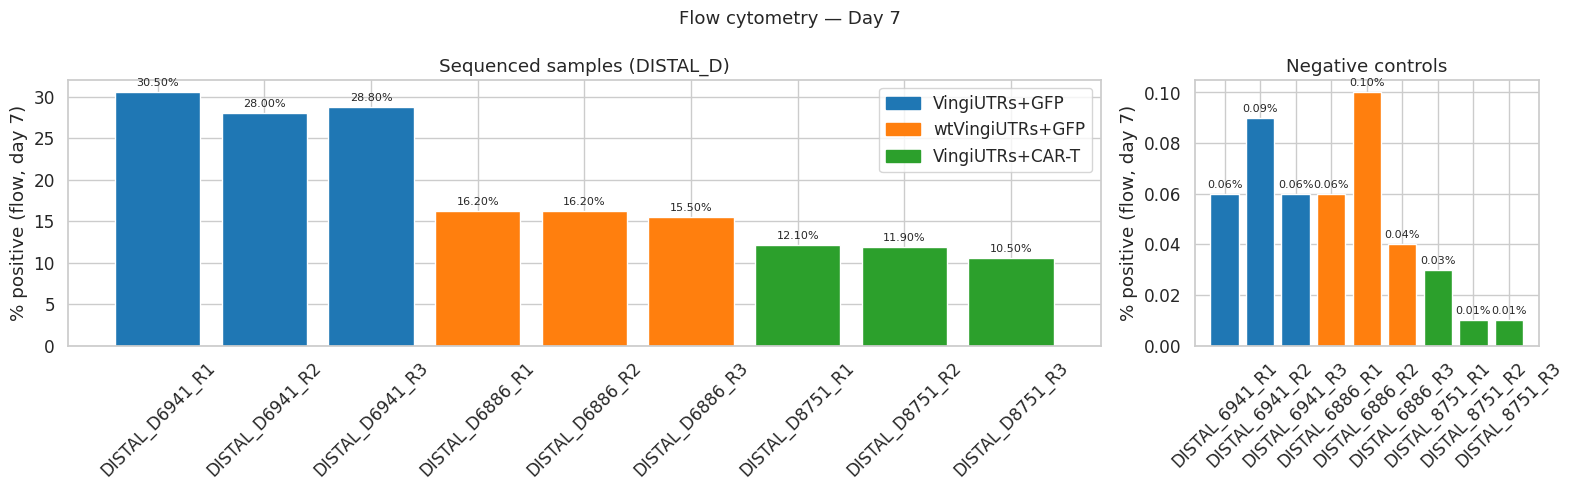

,sample,construct,% positive
0,DISTAL_D6941_R1,VingiUTRs+GFP,30.50
1,DISTAL_D6941_R2,VingiUTRs+GFP,28.00
2,DISTAL_D6941_R3,VingiUTRs+GFP,28.80
3,DISTAL_6941_R1,VingiUTRs+GFP,0.06
4,DISTAL_6941_R2,VingiUTRs+GFP,0.09
5,DISTAL_6941_R3,VingiUTRs+GFP,0.06
6,DISTAL_D6886_R1,wtVingiUTRs+GFP,16.20
7,DISTAL_D6886_R2,wtVingiUTRs+GFP,16.20
8,DISTAL_D6886_R3,wtVingiUTRs+GFP,15.50
9,DISTAL_6886_R1,wtVingiUTRs+GFP,0.06


In [16]:
main_flow = FLOW_D7[FLOW_D7["condition"] == "sequenced"].reset_index(drop=True)
ctrl_flow = FLOW_D7[FLOW_D7["condition"] == "ctrl"].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [3, 1]})

for ax, subset, title in [
    (axes[0], main_flow, "Sequenced samples (DISTAL_D)"),
    (axes[1], ctrl_flow, "Negative controls"),
]:
    colors = [PALETTE[g] for g in subset["group"]]
    bars = ax.bar(subset["sample"], subset["pct"], color=colors, edgecolor="white")
    ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=8)
    ax.set_ylabel("% positive (flow, day 7)")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

handles = [mpatches.Patch(color=PALETTE[g], label=GROUP_LABELS[g]) for g in GROUP_ORDER]
axes[0].legend(handles=handles)

plt.suptitle("Flow cytometry — Day 7", fontsize=13)
plt.tight_layout()
plt.show()

display(FLOW_D7[["sample", "group", "pct"]]
        .assign(construct=lambda df: df["group"].map(GROUP_LABELS))
        .rename(columns={"pct": "% positive"})
        [["sample", "construct", "% positive"]])

## 13. Integration event types — rearrangement buckets

Reproduces `260409.BIO.Buckets_IntegrationEvents.png`.

Each unique integration site (deduplicated to longest read per locus) is classified into one of five buckets based on the vector alignment structure:

| Bucket | Condition |
|---|---|
| **Non rearranged** | Single vector aln, not inverted, 1 human aln |
| **Extra Template** | Single vector aln, not inverted, >1 human aln |
| **Twin Priming** | Rearranged, inverted fragment (overlapping or gapped) |
| **Duplication** | Rearranged, not inverted, overlapping vector hits |
| **Internal Deletion** | Rearranged, not inverted, gapped vector hits |

Loaded 234,696 reads | samples: ['D6886_R1', 'D6886_R2', 'D6886_R3', 'D6941_R1', 'D6941_R2', 'D6941_R3', 'D8751_R1', 'D8751_R2', 'D8751_R3']
Unique IS per sample:
SampleID
D6886_R1     5545
D6886_R2     1945
D6886_R3     6025
D6941_R1    15469
D6941_R2    13073
D6941_R3    10030
D8751_R1     4834
D8751_R2     4856
D8751_R3     4342


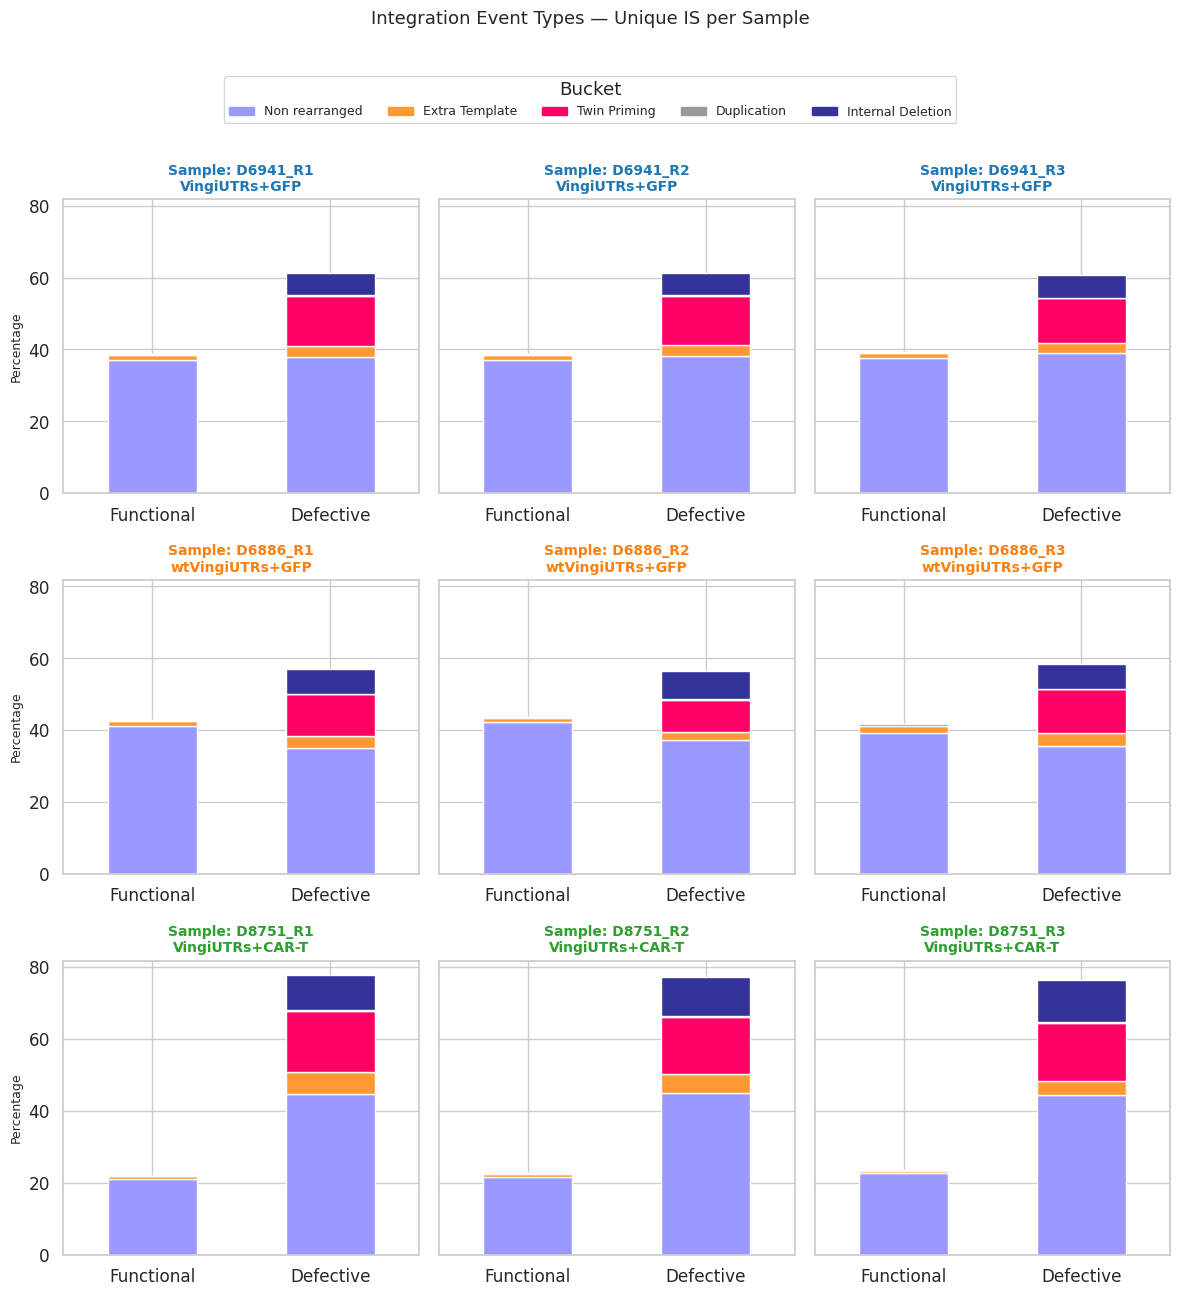


Pool total unique IS per sample:
SampleID
D6886_R1     5545
D6886_R2     1945
D6886_R3     6025
D6941_R1    15469
D6941_R2    13073
D6941_R3    10030
D8751_R1     4834
D8751_R2     4856
D8751_R3     4342

Bucket % per sample (should match 260409.DescriptiveStats.UniqueIS.withPromoter.xlsx):


Bucket                  Duplication  Extra Template  Internal Deletion  \
SampleID Functionality                                                   
D6886_R1 Defective              0.1             3.3                6.9   
         Functional             0.1             1.4                0.0   
D6886_R2 Defective              0.2             2.2                7.7   
         Functional             0.0             1.2                0.0   
D6886_R3 Defective              0.0             3.8                6.9   
         Functional             0.0             2.0                0.0   
D6941_R1 Defective              0.1             3.2                6.1   
         Functional             0.1             1.4                0.0   
D6941_R2 Defective              0.1             3.1                6.1   
         Functional             0.1             1.4                0.0   
D6941_R3 Defective              0.2             2.8                6.4   
         Functional             0.1             1.2                0.0   
D8751_R1 Defective              0.2             6.2                9.9   
         Functional             0.1             0.7                0.0   
D8751_R2 Defective              0.4             5.2               10.6   
         Functional             0.0             1.0                0.0   
D8751_R3 Defective              0.4             3.7               11.5   
         Functional             0.0             0.6                0.0   

Bucket                  Non rearranged  Twin Priming  
SampleID Functionality                                
D6886_R1 Defective                35.1          11.6  
         Functional               41.2           0.3  
D6886_R2 Defective                37.2           9.1  
         Functional               42.2           0.3  
D6886_R3 Defective                35.5          12.1  
         Functional               39.2           0.5  
D6941_R1 Defective                37.9          13.9  
         Functional               36.9           0.4  
D6941_R2 Defective                38.0          13.7  
         Functional               37.1           0.2  
D6941_R3 Defective                39.0          12.4  
         Functional               37.7           0.3  
D8751_R1 Defective                44.7          16.9  
         Functional               21.2           0.1  
D8751_R2 Defective                45.1          16.0  
         Functional               21.5           0.3  
D8751_R3 Defective                44.6          16.2  
         Functional               22.7           0.3

In [17]:
import math
import subprocess
import pandas as pd
import numpy as np
# ── Source: 260409 combined pipeline run — filter_valid_reads-filtered df ─────
# full_df_proper_readlenabovemin_annotatedIS_full contains:
#   - all reads that passed filter_valid_reads (Num_HumanAln==1, Num_VectorAln>=1,
#     UnalnEnds_Limit, WithinVectorAln_UnalnGAPs_Limit, AboveMinReadLen, etc.)
#   - RefID: unique IS cluster assigned by bedtools closest in create_is_matrix.py
#   - Functionality, InvertedFragment, OverlappingVectorHits: pre-computed by Analysis.py
# human_IS in individual ReadInfo.additions files is mostly empty (populated by create_is_matrix);
# using the annotated full df avoids having to replicate bedtools IS clustering.
ANNOT_IS_S3 = (
    "s3://compbio-discovery-shared/nonLTR/distalseq/results/260413_v3/"
    "DISTAL_D6886_D6941_D8751/260413_v3.full_df_proper_readlenabovemin_annotatedIS_full.tsv.gz"
)
ANNOT_LOCAL = "/tmp/260413_v3.annot_is_full.tsv.gz"

print("Downloading annotated IS dataframe …", end=" ", flush=True)
subprocess.run(["aws", "s3", "cp", ANNOT_IS_S3, ANNOT_LOCAL],
               check=True, capture_output=True)
print("done")

ANNOT_COLS = [
    "Read_Name", "Read_Len", "SampleID", "RefID",
    "Num_VectorAln", "Num_Human_Aln",
    "InvertedFragment", "OverlappingVectorHits", "Functionality",
]
adf = pd.read_csv(ANNOT_LOCAL, sep="\t", compression="gzip",
                  usecols=ANNOT_COLS, low_memory=False)
print(f"Loaded {len(adf):,} reads | samples: {sorted(adf['SampleID'].unique())}")

# ── Deduplicate to unique IS per sample (longest read wins — pipeline logic) ──
adf["Num_Human_Aln"] = pd.to_numeric(adf["Num_Human_Aln"], errors="coerce").fillna(0).astype(int)
adf_is = (
    adf.sort_values(["SampleID", "RefID", "Read_Len"], ascending=[True, True, False])
    .groupby(["SampleID", "RefID"], as_index=False)
    .first()
)
print(f"Unique IS per sample:")
print(adf_is.groupby("SampleID").size().sort_index().to_string())

# ── Assign buckets (pipeline logic from find_rearranged_reads.py) ─────────────
adf_is["IntegrationType"] = np.where(adf_is["Num_VectorAln"] == 1, "Single", "Rearranged")

conditions = [
    (adf_is["IntegrationType"] == "Single")     & (adf_is["InvertedFragment"] == "Not inverted") & (adf_is["Num_Human_Aln"] == 1),
    (adf_is["IntegrationType"] == "Single")     & (adf_is["InvertedFragment"] == "Not inverted") & (adf_is["Num_Human_Aln"] >  1),
    (adf_is["IntegrationType"] == "Rearranged") & (adf_is["InvertedFragment"] == "Inverted")     & (adf_is["OverlappingVectorHits"] == "Overlapping"),
    (adf_is["IntegrationType"] == "Rearranged") & (adf_is["InvertedFragment"] == "Inverted")     & (adf_is["OverlappingVectorHits"] == "Gapped"),
    (adf_is["IntegrationType"] == "Rearranged") & (adf_is["InvertedFragment"] == "Not inverted") & (adf_is["OverlappingVectorHits"] == "Overlapping"),
    (adf_is["IntegrationType"] == "Rearranged") & (adf_is["InvertedFragment"] == "Not inverted") & (adf_is["OverlappingVectorHits"] == "Gapped"),
]
bucket_labels = ["Non rearranged", "Extra Template",
                 "Twin Priming",   "Twin Priming",
                 "Duplication",    "Internal Deletion"]
adf_is["Bucket"] = np.select(conditions, bucket_labels, default=None)

# ── Compute PercentOnTotal per sample ─────────────────────────────────────────
adf_classified = adf_is[adf_is["Bucket"].notna()].copy()
pool_totals = adf_classified.groupby("SampleID")["RefID"].count()
pct_df = (
    adf_classified.groupby(["SampleID", "Functionality", "Bucket"]).size()
    .reset_index(name="count")
)
pct_df["PoolTotal"]      = pct_df["SampleID"].map(pool_totals)
pct_df["PercentOnTotal"] = pct_df["count"] / pct_df["PoolTotal"] * 100

# ── Plot — 3 columns per row (one per group), 3 rows ─────────────────────────
BUCKET_COLORS = {
    "Non rearranged":    "#9999FF",
    "Extra Template":    "#FF9933",
    "Twin Priming":      "#FF0066",
    "Duplication":       "#999999",
    "Internal Deletion": "#333399",
}
BUCKET_ORDER = list(BUCKET_COLORS.keys())
FUNC_ORDER   = ["Functional", "Defective"]

# SampleID in the 260409 file: "D6941_R1" etc. → strip "DISTAL_" prefix
SAMPLE_ID_ORDER = [s.replace("DISTAL_", "") for s in SAMPLE_ORDER]

ncols     = 3
nrows     = math.ceil(len(SAMPLE_ORDER) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=True)
axes_flat = axes.flatten()

for ax, (sample, sid) in zip(axes_flat, zip(SAMPLE_ORDER, SAMPLE_ID_ORDER)):
    sub     = pct_df[pct_df["SampleID"] == sid]
    present = [b for b in BUCKET_ORDER if b in sub["Bucket"].values]
    grp     = SAMPLES[sample]["group"]
    ax.set_title(f"Sample: {sid}\n{GROUP_LABELS[grp]}", fontsize=10,
                 color=PALETTE[grp], fontweight="bold")
    if not present:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        continue
    pivot = (
        sub.pivot_table(index="Functionality", columns="Bucket",
                        values="PercentOnTotal", aggfunc="sum", observed=False)
        .reindex(index=FUNC_ORDER)
        .reindex(columns=present)
        .fillna(0)
    )
    pivot.plot(kind="bar", stacked=True, ax=ax,
               color=[BUCKET_COLORS[b] for b in pivot.columns],
               edgecolor="white", legend=False)
    ax.set_ylabel("Percentage", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

for ax in axes_flat[len(SAMPLE_ORDER):]:
    ax.set_visible(False)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=BUCKET_COLORS[b]) for b in BUCKET_ORDER]
fig.legend(legend_handles, BUCKET_ORDER, title="Bucket",
           loc="upper center", bbox_to_anchor=(0.5, 1.03),
           ncol=len(BUCKET_ORDER), fontsize=9)
plt.suptitle("Integration Event Types — Unique IS per Sample", fontsize=13, y=1.08)
plt.tight_layout()
plt.show()

print("\nPool total unique IS per sample:")
print(pool_totals.sort_index().to_string())
print("\nBucket % per sample (should match 260409.DescriptiveStats.UniqueIS.withPromoter.xlsx):")
display(pct_df.pivot_table(index=["SampleID", "Functionality"], columns="Bucket",
                            values="PercentOnTotal", aggfunc="sum", observed=False)
        .fillna(0).round(1))

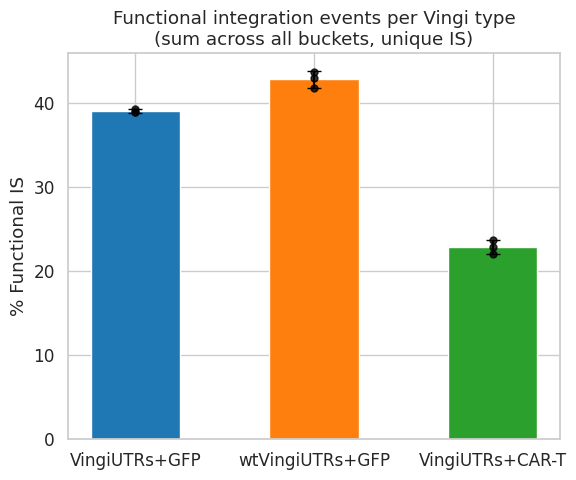

SampleID  pct_functional group
D6886_R1       42.957619 D6886
D6886_R2       43.650386 D6886
D6886_R3       41.709544 D6886
D6941_R1       38.838968 D6941
D6941_R2       38.851067 D6941
D6941_R3       39.272183 D6941
D8751_R1       22.031444 D8751
D8751_R2       22.837727 D8751
D8751_R3       23.629664 D8751

       mean   sd
group           
D6941  39.0  0.2
D6886  42.8  1.0
D8751  22.8  0.8


In [18]:
# ── % Functional IS per Vingi type — bar plot with replicate overlay ──────────
# Sum PercentOnTotal over all bucket types for Functionality == "Functional" per sample
func_pct = (
    pct_df[pct_df["Functionality"] == "Functional"]
    .groupby("SampleID")["PercentOnTotal"]
    .sum()
    .reset_index(name="pct_functional")
)
func_pct["group"] = func_pct["SampleID"].str.split("_R").str[0]   # "D6941_R1" → "D6941"

# Group mean ± SD
agg_func = (
    func_pct.groupby("group")["pct_functional"]
    .agg(mean="mean", sd="std").reset_index().fillna({"sd": 0})
    .set_index("group").reindex(GROUP_ORDER)
)

fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(len(GROUP_ORDER))
bar_w = 0.5

# Bars (mean)
ax.bar(x, agg_func["mean"], bar_w,
       color=[PALETTE[g] for g in GROUP_ORDER], edgecolor="white")

# Error bars (SD)
ax.errorbar(x, agg_func["mean"], yerr=agg_func["sd"],
            fmt="none", color="black", capsize=5, lw=1.5)

# Individual replicate dots
for xi, grp in enumerate(GROUP_ORDER):
    pts = func_pct.loc[func_pct["group"] == grp, "pct_functional"].values
    ax.scatter(np.full(len(pts), x[xi]), pts,
               color="black", s=25, zorder=5, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([GROUP_LABELS[g] for g in GROUP_ORDER])
ax.set_ylabel("% Functional IS")
ax.set_title("Functional integration events per Vingi type\n(sum across all buckets, unique IS)")
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

print(func_pct.sort_values(["group", "SampleID"]).to_string(index=False))
print()
print(agg_func.round(1).to_string())

In [19]:
# Export data underlying the "Functional integration events per Vingi type" figure
out_csv = "/home/ec2-user/distalseq/test/functional_IS_per_vingi_type.csv"

# Per-replicate values
export_per_rep = func_pct[["SampleID", "group", "pct_functional"]].copy()
export_per_rep["group_label"] = export_per_rep["group"].map(GROUP_LABELS)
export_per_rep = export_per_rep.sort_values(["group", "SampleID"]).reset_index(drop=True)

# Group summary (mean ± SD)
export_summary = agg_func.reset_index().rename(
    columns={"mean": "mean_pct_functional", "sd": "sd_pct_functional"})
export_summary["group_label"] = export_summary["group"].map(GROUP_LABELS)

# Write: summary block first, then blank line, then per-replicate block
with open(out_csv, "w") as f:
    f.write("# Group summary (mean ± SD across replicates)\n")
    export_summary.to_csv(f, index=False)
    f.write("\n# Per-replicate values\n")
    export_per_rep.to_csv(f, index=False)

print(f"Saved {out_csv}")

_S3_OUT = "s3://compbio-discovery-shared/nonLTR/distalseq/results/260413_v2/DISTAL_D6886_D6941_D8751/"
import subprocess as _sp
_r = _sp.run(["aws", "s3", "cp", out_csv, _S3_OUT + "functional_IS_per_vingi_type.csv"],
             capture_output=True, text=True)
print("S3 upload:", "OK" if _r.returncode == 0 else _r.stderr.strip())

display(export_summary)
display(export_per_rep)

Saved /home/ec2-user/distalseq/test/functional_IS_per_vingi_type.csv
S3 upload: OK


,group,mean_pct_functional,sd_pct_functional,group_label
0,D6941,38.987406,0.246698,VingiUTRs+GFP
1,D6886,42.772516,0.983572,wtVingiUTRs+GFP
2,D8751,22.832945,0.799121,VingiUTRs+CAR-T


,SampleID,group,pct_functional,group_label
0,D6886_R1,D6886,42.957619,wtVingiUTRs+GFP
1,D6886_R2,D6886,43.650386,wtVingiUTRs+GFP
2,D6886_R3,D6886,41.709544,wtVingiUTRs+GFP
3,D6941_R1,D6941,38.838968,VingiUTRs+GFP
4,D6941_R2,D6941,38.851067,VingiUTRs+GFP
5,D6941_R3,D6941,39.272183,VingiUTRs+GFP
6,D8751_R1,D8751,22.031444,VingiUTRs+CAR-T
7,D8751_R2,D8751,22.837727,VingiUTRs+CAR-T
8,D8751_R3,D8751,23.629664,VingiUTRs+CAR-T
